In [147]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import CategoricalNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler

import sklearn.metrics

In [148]:
data = pd.read_csv("logatta.csv")

In [149]:
data.head(20)

,Age,BusinessTravel,Education,MaritalStatus,OverTime,EmployeeNumber,DailyRate,Gender,accepted for the interview
0,41,Travel_Rarely,2,Single,Yes,1,1102,Female,True
1,49,Travel_Frequently,1,Married,No,2,279,Male,False
2,37,Travel_Rarely,2,Single,Yes,4,1373,Male,False
3,33,Travel_Frequently,4,Married,Yes,5,1392,Female,False
4,27,Travel_Rarely,1,Married,No,7,591,Male,False
5,32,Travel_Frequently,2,Single,No,8,1005,Male,False
6,59,Travel_Rarely,3,Married,Yes,10,1324,Female,False
7,30,Travel_Rarely,1,Divorced,No,11,1358,Male,False
8,38,Travel_Frequently,3,Single,No,12,216,Male,False
9,36,Travel_Rarely,3,Married,No,13,1299,Male,False


In [150]:
encoder_overtime = OrdinalEncoder(categories=[['No', 'Yes']], dtype=int)
encoder_gender = OrdinalEncoder(categories=[['Female', 'Male']], dtype=int)
encoder_travel = OrdinalEncoder(categories=[['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']], dtype=int)
encoder_marital = OrdinalEncoder(categories=[['Single', 'Married', 'Divorced']], dtype=int)

data_converted = data.copy()

#df = pd.get_dummies(df, columns=['MaritalStatus', 'BusinessTravel'], dtype=int)

print(data_converted.dtypes)

#data_converted['OverTime'] = encoder_overtime.transform(data_converted[['OverTime']])
#data_converted['Gender'] = encoder_gender.transform(data_converted[['Gender']])
#data_converted['BusinessTravel'] = encoder_travel.transform(data_converted[['BusinessTravel']])
#data_converted['MaritalStatus'] = encoder_marital.transform(data_converted[['MaritalStatus']])

Age                            int64
BusinessTravel                object
Education                      int64
MaritalStatus                 object
OverTime                      object
EmployeeNumber                 int64
DailyRate                      int64
Gender                        object
accepted for the interview      bool
dtype: object


In [151]:
pd.set_option("display.max_rows", None)
data_converted.head(100)

,Age,BusinessTravel,Education,MaritalStatus,OverTime,EmployeeNumber,DailyRate,Gender,accepted for the interview
0,41,Travel_Rarely,2,Single,Yes,1,1102,Female,True
1,49,Travel_Frequently,1,Married,No,2,279,Male,False
2,37,Travel_Rarely,2,Single,Yes,4,1373,Male,False
3,33,Travel_Frequently,4,Married,Yes,5,1392,Female,False
4,27,Travel_Rarely,1,Married,No,7,591,Male,False
5,32,Travel_Frequently,2,Single,No,8,1005,Male,False
6,59,Travel_Rarely,3,Married,Yes,10,1324,Female,False
7,30,Travel_Rarely,1,Divorced,No,11,1358,Male,False
8,38,Travel_Frequently,3,Single,No,12,216,Male,False
9,36,Travel_Rarely,3,Married,No,13,1299,Male,False


In [152]:
def plot_feature(feature_name):
    x_axis = data_converted["EmployeeNumber"]
    y_axis = data_converted[feature_name]
    icon_style = data_converted["accepted for the interview"]
    
    style_map = {
        False: {'marker': 'o', 'color': 'gray'},
        True: {'marker': '^', 'color': 'crimson'}
    }
    
    fig, ax1 = plt.subplots()
    
    # Loop through the styles and apply them using the mask
    for label, styles in style_map.items():
        mask = (icon_style == label)
        
        ax1.scatter(
            x_axis[mask], 
            y_axis[mask], 
            marker=styles['marker'], 
            color=styles['color'], 
            label=label,
            s=100  # Sets size so they are easy to see
        )
    
    ax1.legend()
    plt.show()

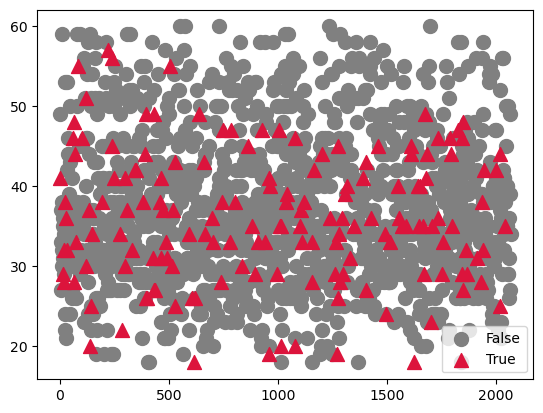

In [153]:
plot_feature("Age")

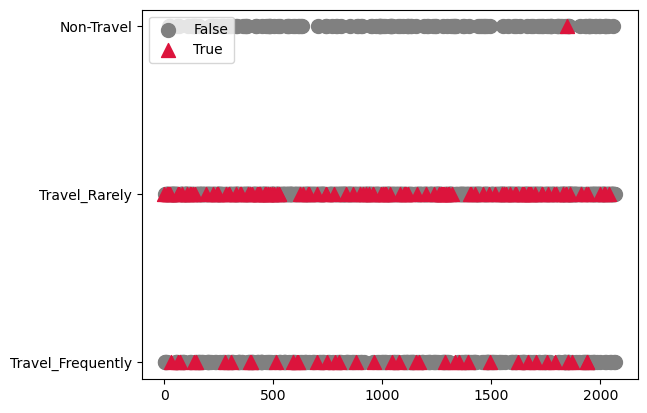

In [154]:
plot_feature("BusinessTravel")

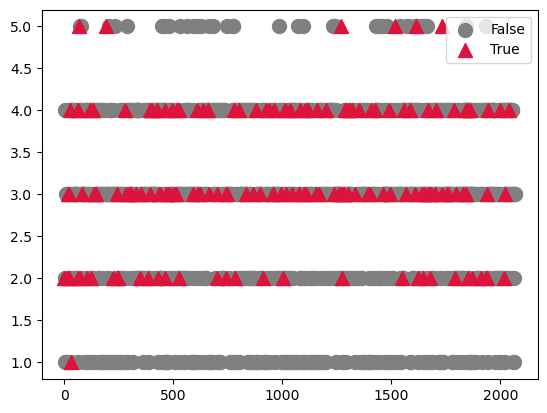

In [155]:
plot_feature("Education")

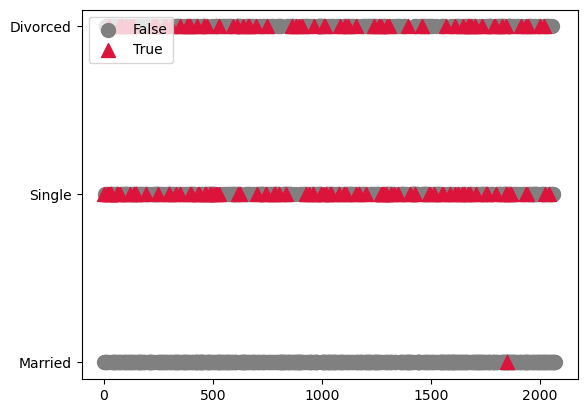

In [156]:
plot_feature("MaritalStatus")

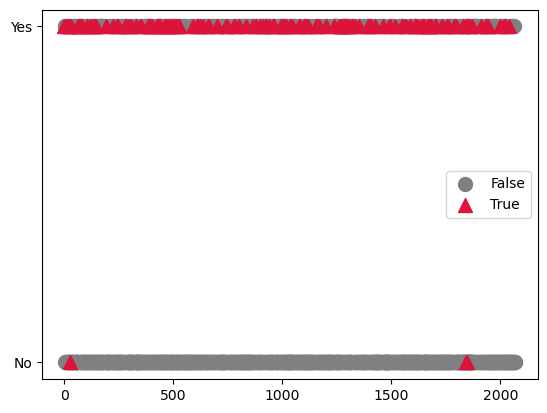

In [157]:
plot_feature("OverTime")

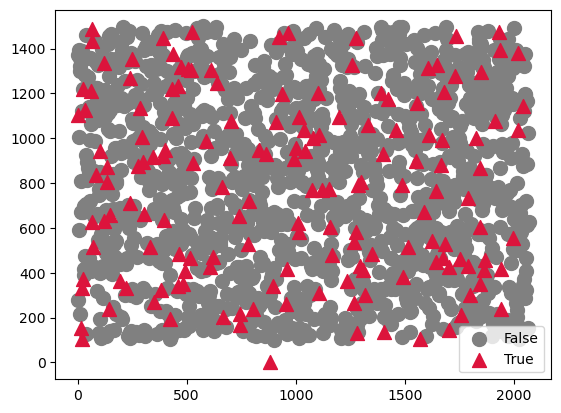

In [158]:
plot_feature("DailyRate")

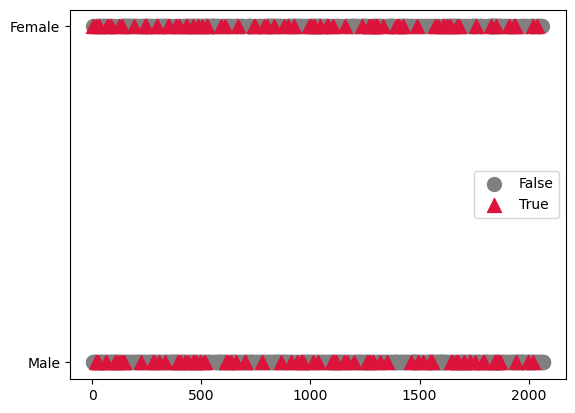

In [159]:
plot_feature("Gender")

# Observations

This company prefers candidates who are not married, and are OK with business trips and overtime (perhaps, business trips are an essential part of the job).

Education and age also are an important factor for the decision.

In [160]:
df = data_converted.drop(columns=["EmployeeNumber", "DailyRate"])

y = df.pop("accepted for the interview")
X = df

In [161]:
print(X.shape)
X.head(10)

(1492, 6)


,Age,BusinessTravel,Education,MaritalStatus,OverTime,Gender
0,41,Travel_Rarely,2,Single,Yes,Female
1,49,Travel_Frequently,1,Married,No,Male
2,37,Travel_Rarely,2,Single,Yes,Male
3,33,Travel_Frequently,4,Married,Yes,Female
4,27,Travel_Rarely,1,Married,No,Male
5,32,Travel_Frequently,2,Single,No,Male
6,59,Travel_Rarely,3,Married,Yes,Female
7,30,Travel_Rarely,1,Divorced,No,Male
8,38,Travel_Frequently,3,Single,No,Male
9,36,Travel_Rarely,3,Married,No,Male


In [162]:
print(y.shape)
y.head(10)

(1492,)


0     True
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: accepted for the interview, dtype: bool

In [163]:
X_train_cv, X_test, y_train_cv, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [164]:
print(X_train_cv.shape, X_test.shape, y_train_cv.shape, y_test.shape)

(1193, 6) (299, 6) (1193,) (299,)


In [165]:
X_train, X_cv, y_train, y_cv = train_test_split(X_train_cv, y_train_cv, test_size=0.2, random_state=42)

In [166]:
print(X_train.shape, X_cv.shape, y_train.shape, y_cv.shape)

(954, 6) (239, 6) (954,) (239,)


In [167]:
#df = pd.get_dummies(df, columns=['MaritalStatus', 'BusinessTravel'], dtype=int)

print(data_converted.dtypes)

X_train['OverTime'] = encoder_overtime.fit_transform(X_train[['OverTime']])
X_train['Gender'] = encoder_gender.fit_transform(X_train[['Gender']])
X_train['BusinessTravel'] = encoder_travel.fit_transform(X_train[['BusinessTravel']])
X_train['MaritalStatus'] = encoder_marital.fit_transform(X_train[['MaritalStatus']])

X_cv['OverTime'] = encoder_overtime.transform(X_cv[['OverTime']])
X_cv['Gender'] = encoder_gender.transform(X_cv[['Gender']])
X_cv['BusinessTravel'] = encoder_travel.transform(X_cv[['BusinessTravel']])
X_cv['MaritalStatus'] = encoder_marital.transform(X_cv[['MaritalStatus']])

X_test['OverTime'] = encoder_overtime.transform(X_test[['OverTime']])
X_test['Gender'] = encoder_gender.transform(X_test[['Gender']])
X_test['BusinessTravel'] = encoder_travel.transform(X_test[['BusinessTravel']])
X_test['MaritalStatus'] = encoder_marital.transform(X_test[['MaritalStatus']])

Age                            int64
BusinessTravel                object
Education                      int64
MaritalStatus                 object
OverTime                      object
EmployeeNumber                 int64
DailyRate                      int64
Gender                        object
accepted for the interview      bool
dtype: object


In [168]:
models = []

models.append(LogisticRegression(max_iter=1000))
models.append(RidgeClassifier())

models.append(GaussianNB())
models.append(MultinomialNB())
models.append(BernoulliNB())
models.append(CategoricalNB())

models.append(KNeighborsClassifier())

model_types = []
model_scores = []
model_f1_scores = []
model_precision_scores = []
model_recall_scores = []

for model in models:
    #model = model_type()
    model.fit(X_train, y_train)

    model_score = model.score(X_cv, y_cv)
    model_type = type(model).__name__

    print(f"model type: {model_type}; score: {model_score}\n")

    y_pred = model.predict(X_cv)

    model_f1_score = sklearn.metrics.f1_score(y_cv, y_pred)
    model_precision = sklearn.metrics.precision_score(y_cv, y_pred, zero_division=0)
    model_recall = sklearn.metrics.recall_score(y_cv, y_pred)

    model_types.append(model_type)
    model_scores.append(model_score)
    model_f1_scores.append(model_f1_score)
    model_precision_scores.append(model_precision)
    model_recall_scores.append(model_recall)

    print(sklearn.metrics.classification_report(y_true = y_cv, y_pred = y_pred, zero_division=0))
    print(sklearn.metrics.confusion_matrix(y_true = y_cv, y_pred = y_pred))

    print("-------------------------------------\n")

model type: LogisticRegression; score: 0.899581589958159

              precision    recall  f1-score   support

       False       0.90      0.99      0.95       209
        True       0.80      0.27      0.40        30

    accuracy                           0.90       239
   macro avg       0.85      0.63      0.67       239
weighted avg       0.89      0.90      0.88       239

[[207   2]
 [ 22   8]]
-------------------------------------

model type: RidgeClassifier; score: 0.8744769874476988

              precision    recall  f1-score   support

       False       0.87      1.00      0.93       209
        True       0.00      0.00      0.00        30

    accuracy                           0.87       239
   macro avg       0.44      0.50      0.47       239
weighted avg       0.76      0.87      0.82       239

[[209   0]
 [ 30   0]]
-------------------------------------

model type: GaussianNB; score: 0.895397489539749

              precision    recall  f1-score   support

   

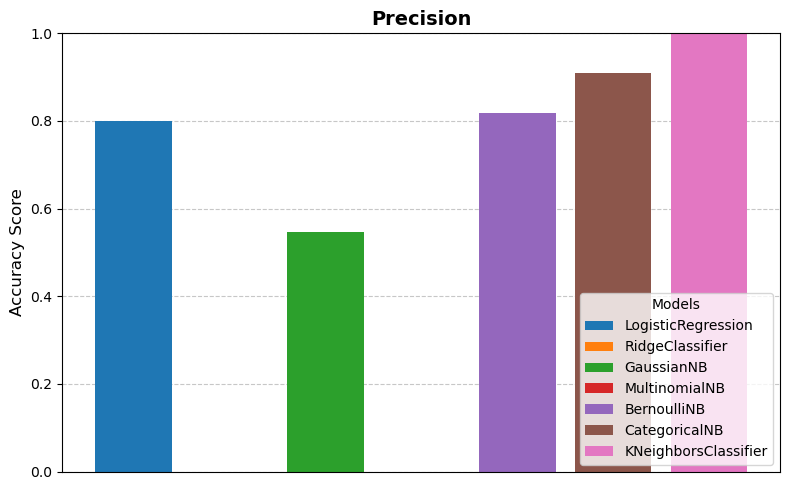

In [169]:
import matplotlib.pyplot as plt
import numpy as np

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars individually to assign distinct labels for the legend
for i in range(len(model_scores)):
    ax.bar(
        x=i, 
        height=model_precision_scores[i], 
        label=model_types[i]
    )

# Formatting the graph
ax.set_ylabel("Accuracy Score", fontsize=12)
ax.set_title("Precision", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.0)  # Adjust limits based on your score range

# Hide x-axis ticks since the legend identifies the models
ax.set_xticks([])

# Add the legend outside or inside the plot
ax.legend(title="Models", loc="lower right", fontsize=10)

# Display gridlines behind bars
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

# Show the final plot
plt.tight_layout()
plt.show()


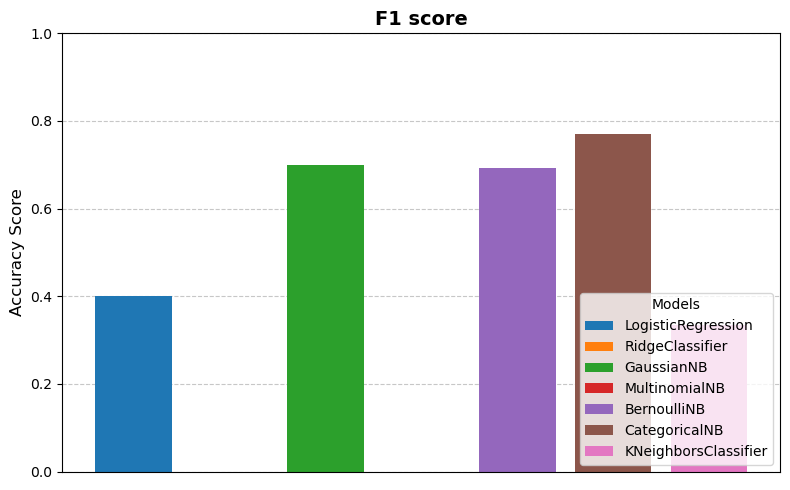

In [170]:
import matplotlib.pyplot as plt
import numpy as np

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars individually to assign distinct labels for the legend
for i in range(len(model_scores)):
    ax.bar(
        x=i, 
        height=model_f1_scores[i], 
        label=model_types[i]
    )

# Formatting the graph
ax.set_ylabel("Accuracy Score", fontsize=12)
ax.set_title("F1 score", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.0)  # Adjust limits based on your score range

# Hide x-axis ticks since the legend identifies the models
ax.set_xticks([])

# Add the legend outside or inside the plot
ax.legend(title="Models", loc="lower right", fontsize=10)

# Display gridlines behind bars
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

# Show the final plot
plt.tight_layout()
plt.show()


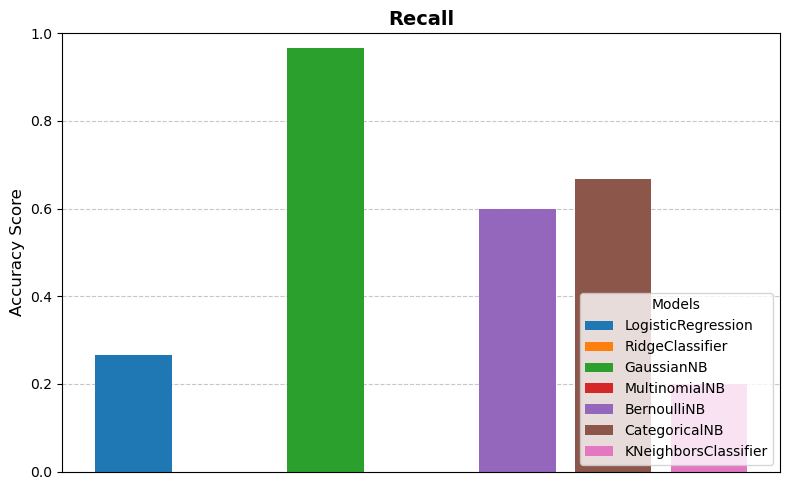

In [171]:
import matplotlib.pyplot as plt
import numpy as np

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars individually to assign distinct labels for the legend
for i in range(len(model_scores)):
    ax.bar(
        x=i, 
        height=model_recall_scores[i], 
        label=model_types[i]
    )

# Formatting the graph
ax.set_ylabel("Accuracy Score", fontsize=12)
ax.set_title("Recall", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.0)  # Adjust limits based on your score range

# Hide x-axis ticks since the legend identifies the models
ax.set_xticks([])

# Add the legend outside or inside the plot
ax.legend(title="Models", loc="lower right", fontsize=10)

# Display gridlines behind bars
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

# Show the final plot
plt.tight_layout()
plt.show()


In [172]:
model_types[2]

'GaussianNB'

In [173]:
model_types[-2]

'CategoricalNB'

In [174]:
model_types[-3]

'BernoulliNB'

In [175]:
models[-2].score(X_test, y_test)

0.9297658862876255

In [176]:
models[2].score(X_test, y_test)

0.8394648829431438

In [177]:
models[-3].score(X_test, y_test)

0.939799331103679

In [178]:
X_test.shape

(299, 6)

In [179]:
y_test.shape

(299,)

# Best models

On the cross-validation set the two Naive Bayes models shows the best results by F1 score: GaussianNB, BernoulliNB, and CategoricalNB.

Since I'd rather have the model give false positive result (to have more candidates to then re-check by a human specialist) than false negative (missed potentially fitting candidates), the choice falls on the model with higher recall: GaussianNB.

In [180]:
gaussian_model = models[2]

In [181]:
y_pred_test = gaussian_model.predict(X_test)

In [182]:
gaussian_model.score(X_test, y_test)

0.8394648829431438

In [183]:
print(sklearn.metrics.classification_report(y_true = y_test, y_pred = y_pred_test))
print(sklearn.metrics.confusion_matrix(y_true = y_test, y_pred = y_pred_test))

              precision    recall  f1-score   support

       False       0.99      0.83      0.90       268
        True       0.39      0.94      0.55        31

    accuracy                           0.84       299
   macro avg       0.69      0.88      0.72       299
weighted avg       0.93      0.84      0.87       299

[[222  46]
 [  2  29]]


In [184]:
model_f1_score = sklearn.metrics.f1_score(y_test, y_pred_test)
model_precision = sklearn.metrics.precision_score(y_test, y_pred_test)
model_recall = sklearn.metrics.recall_score(y_test, y_pred_test)

In [185]:
model_f1_score

0.5471698113207547

In [186]:
model_precision

0.38666666666666666

In [187]:
model_recall

0.9354838709677419

In [188]:
X_test[:30]

,Age,BusinessTravel,Education,MaritalStatus,OverTime,Gender
949,39,1,2,0,0,1
900,36,2,3,1,0,1
1338,30,1,3,0,0,1
983,34,1,4,0,0,0
958,34,1,3,2,0,1
561,52,1,4,1,0,1
481,34,1,2,1,1,1
303,31,1,3,1,0,1
342,31,1,4,0,1,0
244,45,1,3,1,0,1


In [189]:
y_pred_test[:30]

array([False, False, False, False, False, False,  True, False,  True,
       False, False, False, False,  True, False, False, False,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False, False])

In [190]:
y_test.head(30).to_numpy()

array([False, False, False, False, False, False, False, False,  True,
       False, False, False, False,  True, False, False, False, False,
        True,  True, False, False, False, False, False, False, False,
       False, False, False])

# Feature scaling

Let's now add MinMaxScaler for features (Standard scaler uses negative values, and not all models support them).
For convenience I'm adding these two lines of code to replace all models with a pipeline:

```python
for i in range(len(models)):
    models[i] = make_pipeline(MinMaxScaler(), models[i])
```

and then making an extra little change in the main loop to have the original model type names instead of the "Pipeline" string:

```python
model_type = type(model[-1]).__name__
```

In [191]:
models = []

models.append(LogisticRegression(max_iter=1000))
models.append(RidgeClassifier())

models.append(GaussianNB())
models.append(MultinomialNB())
models.append(BernoulliNB())
models.append(CategoricalNB())

models.append(KNeighborsClassifier())

for i in range(len(models)):
    models[i] = make_pipeline(MinMaxScaler(), models[i])

model_types = []
model_scores = []
model_f1_scores = []
model_precision_scores = []
model_recall_scores = []

for model in models:
    model.fit(X_train, y_train)

    model_score = model.score(X_cv, y_cv)
    model_type = type(model[-1]).__name__

    print(f"model type: {model_type}; score: {model_score}\n")

    y_pred = model.predict(X_cv)

    model_f1_score = sklearn.metrics.f1_score(y_cv, y_pred)
    model_precision = sklearn.metrics.precision_score(y_cv, y_pred, zero_division=0)
    model_recall = sklearn.metrics.recall_score(y_cv, y_pred)

    model_types.append(model_type)
    model_scores.append(model_score)
    model_f1_scores.append(model_f1_score)
    model_precision_scores.append(model_precision)
    model_recall_scores.append(model_recall)

    print(sklearn.metrics.classification_report(y_true = y_cv, y_pred = y_pred, zero_division=0))
    print(sklearn.metrics.confusion_matrix(y_true = y_cv, y_pred = y_pred))

    print("-------------------------------------\n")

model type: LogisticRegression; score: 0.891213389121339

              precision    recall  f1-score   support

       False       0.90      0.99      0.94       209
        True       0.75      0.20      0.32        30

    accuracy                           0.89       239
   macro avg       0.82      0.60      0.63       239
weighted avg       0.88      0.89      0.86       239

[[207   2]
 [ 24   6]]
-------------------------------------

model type: RidgeClassifier; score: 0.8744769874476988

              precision    recall  f1-score   support

       False       0.87      1.00      0.93       209
        True       0.00      0.00      0.00        30

    accuracy                           0.87       239
   macro avg       0.44      0.50      0.47       239
weighted avg       0.76      0.87      0.82       239

[[209   0]
 [ 30   0]]
-------------------------------------

model type: GaussianNB; score: 0.895397489539749

              precision    recall  f1-score   support

   

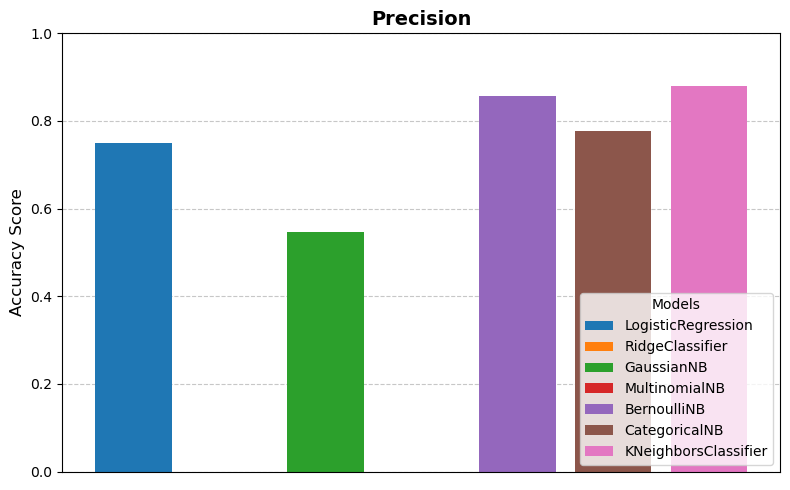

In [192]:
import matplotlib.pyplot as plt
import numpy as np

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars individually to assign distinct labels for the legend
for i in range(len(model_scores)):
    ax.bar(
        x=i, 
        height=model_precision_scores[i], 
        label=model_types[i]
    )

# Formatting the graph
ax.set_ylabel("Accuracy Score", fontsize=12)
ax.set_title("Precision", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.0)  # Adjust limits based on your score range

# Hide x-axis ticks since the legend identifies the models
ax.set_xticks([])

# Add the legend outside or inside the plot
ax.legend(title="Models", loc="lower right", fontsize=10)

# Display gridlines behind bars
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

# Show the final plot
plt.tight_layout()
plt.show()


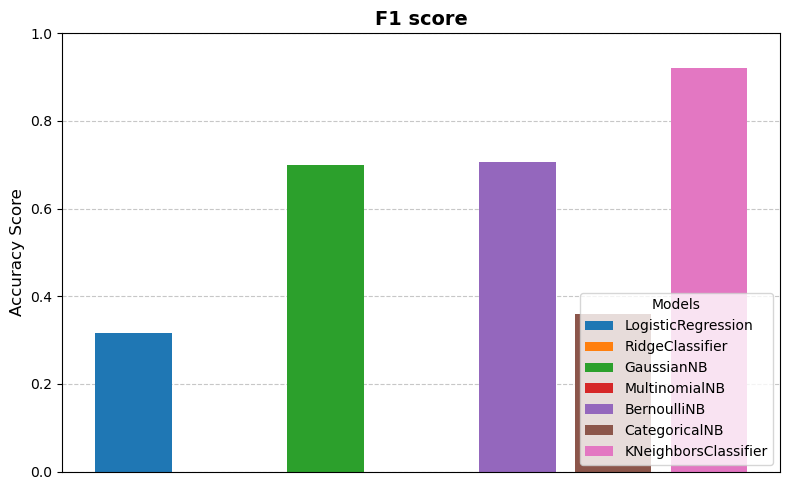

In [193]:
import matplotlib.pyplot as plt
import numpy as np

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars individually to assign distinct labels for the legend
for i in range(len(model_scores)):
    ax.bar(
        x=i, 
        height=model_f1_scores[i], 
        label=model_types[i]
    )

# Formatting the graph
ax.set_ylabel("Accuracy Score", fontsize=12)
ax.set_title("F1 score", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.0)  # Adjust limits based on your score range

# Hide x-axis ticks since the legend identifies the models
ax.set_xticks([])

# Add the legend outside or inside the plot
ax.legend(title="Models", loc="lower right", fontsize=10)

# Display gridlines behind bars
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

# Show the final plot
plt.tight_layout()
plt.show()


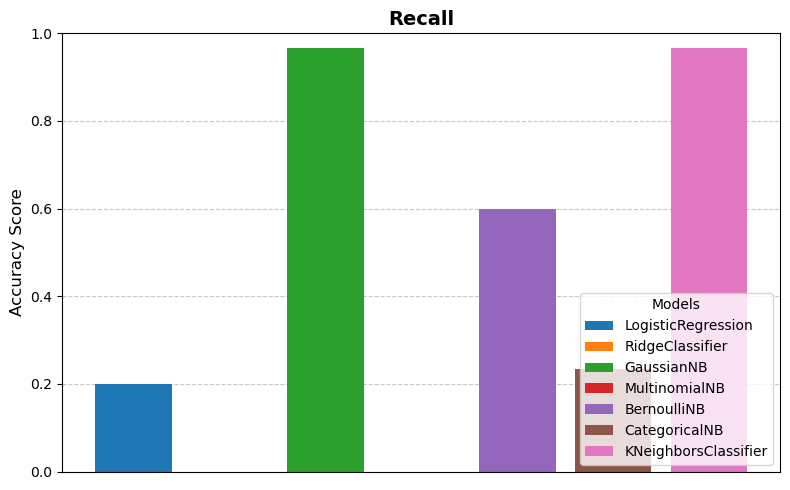

In [194]:
import matplotlib.pyplot as plt
import numpy as np

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars individually to assign distinct labels for the legend
for i in range(len(model_scores)):
    ax.bar(
        x=i, 
        height=model_recall_scores[i], 
        label=model_types[i]
    )

# Formatting the graph
ax.set_ylabel("Accuracy Score", fontsize=12)
ax.set_title("Recall", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.0)  # Adjust limits based on your score range

# Hide x-axis ticks since the legend identifies the models
ax.set_xticks([])

# Add the legend outside or inside the plot
ax.legend(title="Models", loc="lower right", fontsize=10)

# Display gridlines behind bars
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

# Show the final plot
plt.tight_layout()
plt.show()

# KNeighborsClassifier is the new leader

Now the KNeighborsClassifier model not only ties the GaussianNB model in the recall metric, but also shows better performance in the precision metric.


In [195]:
best_model = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=5))

In [196]:
model_scores = []
model_f1_scores = []
model_precision_scores = []
model_recall_scores = []

model_k = range(1, 20)

for k in model_k:
    model = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=k))

    model.fit(X_train, y_train)
    
    model_score = model.score(X_cv, y_cv)
    model_type = type(model).__name__
    
    print(f"K: {k}; score: {model_score}\n")
    
    y_pred = model.predict(X_cv)
    
    model_f1_score = sklearn.metrics.f1_score(y_cv, y_pred)
    model_precision = sklearn.metrics.precision_score(y_cv, y_pred, zero_division=0)
    model_recall = sklearn.metrics.recall_score(y_cv, y_pred)
    
    model_scores.append(model_score)
    model_f1_scores.append(model_f1_score)
    model_precision_scores.append(model_precision)
    model_recall_scores.append(model_recall)
    
    print(sklearn.metrics.classification_report(y_true = y_cv, y_pred = y_pred, zero_division=0))
    print(sklearn.metrics.confusion_matrix(y_true = y_cv, y_pred = y_pred))
    
    print("-------------------------------------\n")

K: 1; score: 0.9707112970711297

              precision    recall  f1-score   support

       False       0.98      0.99      0.98       209
        True       0.93      0.83      0.88        30

    accuracy                           0.97       239
   macro avg       0.95      0.91      0.93       239
weighted avg       0.97      0.97      0.97       239

[[207   2]
 [  5  25]]
-------------------------------------

K: 2; score: 0.9707112970711297

              precision    recall  f1-score   support

       False       0.97      1.00      0.98       209
        True       1.00      0.77      0.87        30

    accuracy                           0.97       239
   macro avg       0.98      0.88      0.93       239
weighted avg       0.97      0.97      0.97       239

[[209   0]
 [  7  23]]
-------------------------------------

K: 3; score: 0.9790794979079498

              precision    recall  f1-score   support

       False       0.99      0.99      0.99       209
        True  

In [197]:
best_model.fit(X_train, y_train)

best_model.score(X_test, y_test)

0.9732441471571907

In [198]:
y_pred_test = best_model.predict(X_test)
y_pred_cv = best_model.predict(X_cv)

In [199]:
print(sklearn.metrics.classification_report(y_true = y_test, y_pred = y_pred_test))
print(sklearn.metrics.confusion_matrix(y_true = y_test, y_pred = y_pred_test))

              precision    recall  f1-score   support

       False       0.99      0.98      0.98       268
        True       0.83      0.94      0.88        31

    accuracy                           0.97       299
   macro avg       0.91      0.96      0.93       299
weighted avg       0.98      0.97      0.97       299

[[262   6]
 [  2  29]]


In [200]:
model_f1_score = sklearn.metrics.f1_score(y_test, y_pred_test)
model_precision = sklearn.metrics.precision_score(y_test, y_pred_test)
model_recall = sklearn.metrics.recall_score(y_test, y_pred_test)

In [201]:
model_f1_score

0.8787878787878788

In [202]:
model_precision

0.8285714285714286

In [203]:
model_recall

0.9354838709677419

In [204]:
X_test[:30]

,Age,BusinessTravel,Education,MaritalStatus,OverTime,Gender
949,39,1,2,0,0,1
900,36,2,3,1,0,1
1338,30,1,3,0,0,1
983,34,1,4,0,0,0
958,34,1,3,2,0,1
561,52,1,4,1,0,1
481,34,1,2,1,1,1
303,31,1,3,1,0,1
342,31,1,4,0,1,0
244,45,1,3,1,0,1


In [205]:
y_pred_test[:30]

array([False, False, False, False, False, False, False, False,  True,
       False, False, False, False,  True, False, False, False, False,
        True,  True, False, False, False, False, False, False, False,
       False, False, False])

In [206]:
y_test.head(30).to_numpy()

array([False, False, False, False, False, False, False, False,  True,
       False, False, False, False,  True, False, False, False, False,
        True,  True, False, False, False, False, False, False, False,
       False, False, False])